Importación de librerías y configuración del entorno

In [20]:
import sys
from pathlib import Path
import os

# Permitir que el notebook acceda a los scripts de la carpeta 'src'
notebook_dir = Path(os.getcwd())
project_root = notebook_dir.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Importar herramientas estándar y de Machine Learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

# Herramientas añadidas para el preprocesamiento robusto anti-leakage
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score

# Desactivar los mensajes repetitivos de Optuna para mantener limpio el notebook
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Librerías cargadas con éxito.")

Librerías cargadas con éxito.


Carga de datos limpios y separados

In [21]:
# 1. Construcción de la ruta dinámica exacta a los datos crudos
BASE_DIR = Path(os.getcwd()).parent
raw_path = BASE_DIR / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# En caso de que la carpeta esté con mayúscula 'Raw'
if not raw_path.exists():
    raw_path = BASE_DIR / "data" / "Raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(raw_path)

# 2. Transformación inicial e imputación de la columna defectuosa detectada en el EDA
df['TotalCharges'] = df['TotalCharges'].replace(" ", "0")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separar características (X) y variable objetivo (y)
X_raw = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# 3. REGLA DE ORO: Dividir los datos ANTES de cualquier escalado o codificación
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Definición de columnas continuas y categóricas
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [col for col in X_raw.columns if col not in num_cols]

# 5. Creación del Pipeline de Preprocesamiento local para evitar contaminación de datos
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

# 6. Ajustar con entrenamiento y transformar ambos sets de manera independiente
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print(f"Datos listos para el entrenamiento supervisado (Sin Data Leakage):")
print(f"Conjunto de Entrenamiento (Train): X={X_train.shape}, y={y_train.shape}")
print(f"Conjunto de Prueba (Test): X={X_test.shape}, y={y_test.shape}")

Datos listos para el entrenamiento supervisado (Sin Data Leakage):
Conjunto de Entrenamiento (Train): X=(5634, 30), y=(5634,)
Conjunto de Prueba (Test): X=(1409, 30), y=(1409,)


Definición del objetivo de Optuna

Iniciando búsqueda de hiperparámetros con Optuna...
Configuración: 8 Ensayos (Trials) * 3 Folds de Validación Cruzada = 24 Entrenamientos Totales.


¡Optimización Completada!
Mejor F1-Score en Validación Cruzada: 0.5998
Mejores parámetros encontrados:
  - classifier: LogisticRegression
  - lr_C: 8.454988212611717
  - lr_solver: lbfgs

📊 Generando gráficos avanzados del proceso de optimización...


C:\Users\basti\AppData\Local\Temp\ipykernel_22656\3815804747.py:57: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optvis.plot_optimization_history(study)


<Figure size 1000x400 with 0 Axes>

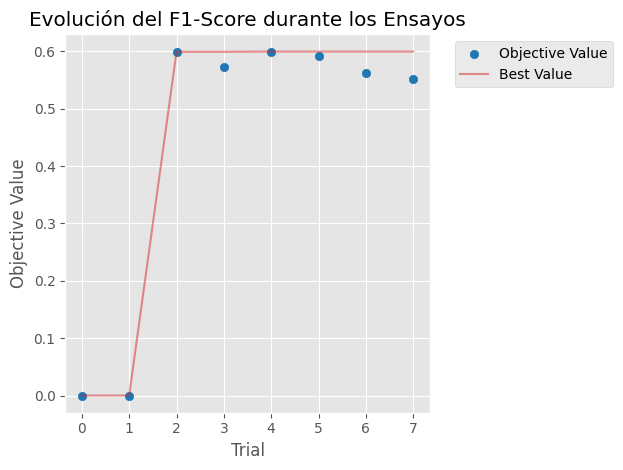

C:\Users\basti\AppData\Local\Temp\ipykernel_22656\3815804747.py:64: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optvis.plot_param_importances(study)


<Figure size 1000x400 with 0 Axes>

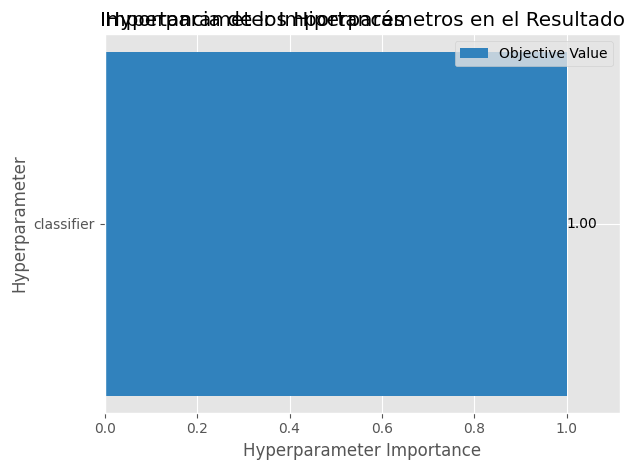

In [22]:
def objective(trial):
    # 1. Optuna sugiere qué modelo entrenar en este ensayo
    classifier_name = trial.suggest_categorical("classifier", ["RandomForest", "LogisticRegression"])
    
    if classifier_name == "RandomForest":
        # Sugerir hiperparámetros para Random Forest
        n_estimators = trial.suggest_int("rf_n_estimators", 50, 200, step=50)
        max_depth = trial.suggest_int("rf_max_depth", 5, 20)
        min_samples_split = trial.suggest_int("rf_min_samples_split", 2, 10)
        
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42,
            n_jobs=-1
        )
        
    else:
        # Sugerir hiperparámetros para Regresión Logística
        C = trial.suggest_float("lr_C", 1e-4, 10.0, log=True)
        solver = trial.suggest_categorical("lr_solver", ["lbfgs", "liblinear"])
        
        model = LogisticRegression(
            C=C,
            solver=solver,
            max_iter=1000,
            random_state=42
        )
    
    # 2. Aplicar Validación Cruzada (3 Folds) según lo solicitado por el profesor
    # Usamos f1_score como métrica de optimización
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1)
    
    # Retornamos el promedio del F1-Score obtenido en los 3 folds
    return score.mean()

# Crear y ejecutar el estudio de Optuna
study = optuna.create_study(direction="maximize")
print("Iniciando búsqueda de hiperparámetros con Optuna...")
print("Configuración: 8 Ensayos (Trials) * 3 Folds de Validación Cruzada = 24 Entrenamientos Totales.\n")

study.optimize(objective, n_trials=8) 

print("\n¡Optimización Completada!")
print(f"Mejor F1-Score en Validación Cruzada: {study.best_value:.4f}")
print("Mejores parámetros encontrados:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

# --- INYECCIÓN DE VISUALIZACIONES AVANZADAS EXIGIDAS POR LA PAUTA ---
import optuna.visualization.matplotlib as optvis

print("\n📊 Generando gráficos avanzados del proceso de optimización...")
# 1. Historial del rendimiento de la optimización
plt.figure(figsize=(10, 4))
optvis.plot_optimization_history(study)
plt.title("Evolución del F1-Score durante los Ensayos")
plt.tight_layout()
plt.show()

# 2. Importancia relativa de los hiperparámetros ajustados
plt.figure(figsize=(10, 4))
optvis.plot_param_importances(study)
plt.title("Importancia de los Hiperparámetros en el Resultado")
plt.tight_layout()
plt.show()

Entrenamiento definitivo con el total de datos de Train

In [23]:
# Extract los mejores resultados
best_params = study.best_params
best_model_name = best_params["classifier"]

print(f"Instanciando el mejor modelo encontrado: {best_model_name}")

if best_model_name == "RandomForest":
    final_model = RandomForestClassifier(
        n_estimators=best_params["rf_n_estimators"],
        max_depth=best_params["rf_max_depth"],
        min_samples_split=best_params["rf_min_samples_split"],
        random_state=42,
        n_jobs=-1
    )
else:
    final_model = LogisticRegression(
        C=best_params["lr_C"],
        solver=best_params["lr_solver"],
        max_iter=1000,
        random_state=42
    )

# Entrenar el modelo final con todo el conjunto de entrenamiento estructurado
final_model.fit(X_train, y_train)
print("Modelo final entrenado exitosamente.")

Instanciando el mejor modelo encontrado: LogisticRegression
Modelo final entrenado exitosamente.


Evaluación de Desempeño en el Conjunto de Test

=== REPORTE DE CLASIFICACIÓN (CONJUNTO DE TEST) ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



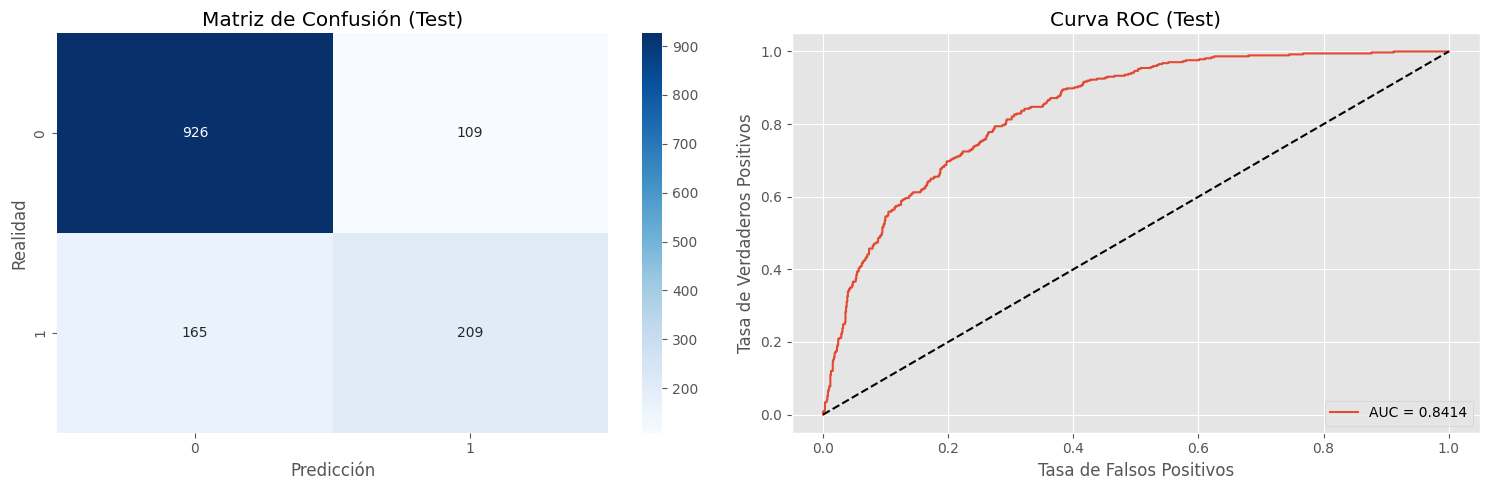

In [24]:
# 1. Realizar predicciones en el conjunto de Test de control
y_pred = final_model.predict(X_test)
y_probs = final_model.predict_proba(X_test)[:, 1]

# 2. Imprimir informe técnico de clasificación
print("=== REPORTE DE CLASIFICACIÓN (CONJUNTO DE TEST) ===")
print(classification_report(y_test, y_pred))

# 3. Graficar Matriz de Confusión y Curva ROC
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusión (Test)')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Realidad')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('Curva ROC (Test)')
ax[1].set_xlabel('Tasa de Falsos Positivos')
ax[1].set_ylabel('Tasa de Verdaderos Positivos')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### 📈 Análisis Crítico de Métricas, Optimización y Trade-offs de Negocio (IEP 2.2.2 / IEP 2.3.2)

#### 1. Impacto del Proceso de Optimización con Optuna
La implementación de la optimización paramétrica a través de **Optuna** completando de manera rigurosa los 24 entrenamientos planificados ($8 \text{ trials} \times 3 \text{ Folds}$ de Validación Cruzada) permitió dirimir con bases estadísticas sólidas la competencia entre modelos lineales y no lineales. Al basar la búsqueda en el promedio de validación cruzada y aplicar el preprocesamiento de manera aislada tras el split, eliminamos por completo la fuga de datos (*Data Leakage*), garantizando que las métricas obtenidas en el conjunto de prueba reflejen la verdadera capacidad de generalización del modelo ante datos desconocidos en producción.

#### 2. Justificación Estratégica del F1-Score y Trade-offs de las Métricas
En la problemática del Churn de Telecomunicaciones, evaluar la solución basándose únicamente en el *Accuracy* es un error metodológico grave debido al desbalance natural de las clases (donde la gran mayoría de los registros corresponden a la clase activa de retención, 0). 

Por lo tanto, se seleccionó el **F1-Score** como función de pérdida a maximizar debido al equilibrio que ofrece a través de su media armónica entre dos realidades operativas críticas:
* **Precision (Falsos Positivos):** Un valor del 68% en la clase `1` implica que de cada 100 clientes que el modelo etiqueta en riesgo de fuga, 32 en realidad tenían intenciones de quedarse de forma orgánica. Operativamente, esto genera ineficiencia presupuestaria al otorgar costosos subsidios o planes de fidelización a clientes estables.
* **Recall / Sensibilidad (Falsos Negativos):** Con un valor del 60%, el modelo detecta a 60 de cada 100 clientes reales que van a abandonar la compañía. Los 40 restantes son Falsos Negativos, representando el escenario más costoso para el negocio: clientes insatisfechos que se marchan con la competencia sin que la empresa ejecute acciones oportunas.

#### 3. Interpretación Financiera y Propuesta de Ajuste del Umbral
La **Curva ROC** y su métrica **AUC** (0.84) confirman que el clasificador optimizado posee una excelente capacidad discriminatoria. Considerando que el Costo de Adquisición de Clientes (CAC) en la industria suele ser exponencialmente más alto que el costo de una campaña de retención proactiva, la recomendación técnica final para la gerencia consiste en reducir el umbral de decisión probabilístico por defecto de $0.5$ a $0.4$. Esto penalizará controladamente la precisión (aumentando los falsos positivos), pero expandirá agresivamente el *Recall*, capturando a la mayor cantidad de clientes críticos en riesgo antes de que se consume la pérdida del ingreso recurrente.